# Zadanie 4: obliczenia ewolucyjne

Termin realizacji: 4 maja 2026

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Zmodyfikuj przykład "iterative method" z notatnika `tsp_lazy_constraints.ipynb` tak, aby rozwiązywał [problem podróżującego konsumenta](https://en.wikipedia.org/wiki/Traveling_purchaser_problem). Przykładowe problemy generuje poniższa funkcja `generate_random_tpp`. Przyjmij, że wszystkie miasta muszą być odwiedzone niezależnie od tego czy dokonany tam będzie zakup czy też nie. W rozwiązaniu wypisz w którym mieście kupione będą poszczególne przedmioty oraz narysuj trasę.
2. Zmodyfikuj analogicznie kod z notatnika `tsp-genetic.ipynb` tak aby rozwiązywał ten sam problem. Porównaj wydajność (czas obliczeń i wartość funkcji kosztu) dla dziewięciu losowych problemów, po trzy dla rozmiarów (n=50, k=20), (n=50, k=50) oraz (n=100, k=100). Dobierz parametry algorytmu genetycznego tak, aby czas działania nie przekraczał w żadnym przypadku minuty.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Dodaj do problemu wagę przedmiotów, powiększającą koszt rozwiązania o długość trasy od miejsca zakupu do końca trasy pomnożoną przez wagę przedmiotu i stały współczynnik dobrany tak, aby dla przedmiotu średniej wagi jego transport między najbardziej odległymi miastami (w linii prostej) wynosił około 1% ceny. Nie dodawaj tego składnika do funkcji kosztu zaimplementowanej w JuMP, ale uwzględnij go w algorytmie genetycznym. Porównaj jakość rozwiązań uzyskanych przez oba algorytmy z uwzględnieniem wagi i bez.
3. Zaimplementuj dodatkowo [krzyżowanie PMX](https://en.wikipedia.org/wiki/Crossover_(genetic_algorithm)#Partially_mapped_crossover_(PMX)) i porównaj wydajność z tym opartym o inwersję permutacji.

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zmodyfikuj problem tak, aby konsument nie musiał odwiedzać miast w których niczego nie kupuje.
3. Dodaj dodatkowo do porównania zmodyfikowany dla problemu podróżującego konsumenta przykład "lazy constraints" z notatnika `tsp_lazy_constraints.ipynb`. Dane do problemu powinny być generowane tak, aby konsument w zwracanym rozwiązaniu odwiedzał przynajmniej 3 miasta i omijał przynajmniej 2.


In [3]:
import Pkg;
Pkg.add("JuMP")
Pkg.add("GLPK")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
   Installed GLPK_jll ─ v5.0.1+1
   Installed GLPK ───── v1.2.1
  Installing 1 artifacts
   Installed artifact GLPK                     3.1 MiB
    Updating `~/.julia/environments/v1.12/Project.toml`
  [60bf3e95] + GLPK v1.2.1
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [60bf3e95] + GLPK v1.2.1
  [e8aa6df9] + GLPK_jll v5.0.1+1
  [781609d7] + GMP_jll v6.3.0+2
Precompiling packages...
    724.6 ms  ✓ GLPK_jll
   5730.6 ms  ✓ GLPK
  2 dependencies successfully precompiled in 7 seconds. 257 already precompiled.


# ZADANIE 1

In [2]:
using JuMP
import GLPK
import Random
import Plots

function generate_random_tpp(n, k; random_seed = 1)
    rng = Random.MersenneTwister(random_seed)
    # distance matrix
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]

    cost_item_city = 50 .+ 100 .* rand(rng, k, n) # cost_item_city[num_item, num_city]

    return X, Y, d, cost_item_city
end

n = 100
k = 100
X, Y, d, cost_item_city = generate_random_tpp(n, k)

([9.913970137863682, 70.19797138879542, 50.3261785841856, 87.58412053070398, 95.34654118744876, 50.7810571056071, 78.97511635624403, 7.125413261100788, 13.837807897217225, 39.31891799217675  …  84.87369607977678, 61.680928138712, 5.665730912653899, 15.622563304879634, 36.90767228785501, 70.07597765092129, 79.43901471209098, 46.482254570311675, 68.59072330642508, 86.69884288310024], [96.78179466896867, 56.23453714649542, 67.44638756669107, 7.1115103002265645, 92.78034391338332, 34.57366887562756, 76.53412034001651, 33.078576899782796, 62.27235533684083, 31.31072581673351  …  1.4463814325218927, 42.253985947804495, 53.81635009641501, 76.50117040708963, 27.74238915740479, 60.20183753580153, 19.81346291572821, 90.60507365183767, 31.10234142135033, 21.085230265206945], [0.0 72.65150307747324 … 88.07242440917794 107.82340444001487; 72.65150307747324 0.0 … 25.183536454701592 38.829789264256306; … ; 88.07242440917794 25.183536454701592 … 0.0 20.69411777577625; 107.82340444001487 38.82978926425

### Metoda iteracyjna

In [6]:
function build_tpp_model(d, n, cost_item_city, m)
    model = Model(GLPK.Optimizer)

    @variable(model, x[1:n, 1:n], Bin, Symmetric)
    @variable(model, z[1:m, 1:n], Bin)

    @objective(model, Min, (sum(d .* x)/2) + sum(cost_item_city .* z))

    @constraint(model, [i in 1:n], sum(x[i, :]) == 2)
    @constraint(model, [i in 1:n], x[i, i] == 0)

    @constraint(model, [k in 1:m], sum(z[k,:]) == 1)
    return model
end

build_tpp_model (generic function with 1 method)

In [4]:
function subtour(edges::Vector{Tuple{Int,Int}}, n)
    shortest_subtour, unvisited = collect(1:n), Set(collect(1:n))
    while !isempty(unvisited)
        this_cycle, neighbors = Int[], unvisited
        while !isempty(neighbors)
            current = pop!(neighbors)
            push!(this_cycle, current)
            if length(this_cycle) > 1
                pop!(unvisited, current)
            end
            neighbors =
                [j for (i, j) in edges if i == current && j in unvisited]
        end
        if length(this_cycle) < length(shortest_subtour)
            shortest_subtour = this_cycle
        end
    end
    return shortest_subtour
end

subtour (generic function with 1 method)

In [7]:
function selected_edges(x::Matrix{Float64}, n)
    return Tuple{Int,Int}[(i, j) for i in 1:n, j in 1:n if x[i, j] > 0.5]
end

selected_edges (generic function with 1 method)

In [8]:
subtour(x::Matrix{Float64}) = subtour(selected_edges(x, size(x, 1)), size(x, 1))
subtour(x::AbstractMatrix{VariableRef}) = subtour(value.(x))

subtour (generic function with 3 methods)

In [9]:
iterative_model = build_tpp_model(d, n, cost_item_city, k)
optimize!(iterative_model)
@assert is_solved_and_feasible(iterative_model)
time_iterated = solve_time(iterative_model)
cycle = subtour(iterative_model[:x])
while 1 < length(cycle) < n
    println("Found cycle of length $(length(cycle))")
    S = [(i, j) for (i, j) in Iterators.product(cycle, cycle) if i < j]
    @constraint(
        iterative_model,
        sum(iterative_model[:x][i, j] for (i, j) in S) <= length(cycle) - 1,
    )
    optimize!(iterative_model)
    @assert is_solved_and_feasible(iterative_model)
    global time_iterated += solve_time(iterative_model)
    global cycle = subtour(iterative_model[:x])
end

objective_value(iterative_model)

Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 4
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 4
Found cycle of length 5
Found cycle of length 6
Found cycle of length 5
Found cycle of length 3
Found cycle of length 4
Found cycle of length 6
Found cycle of length 4
Found cycle of length 8
Found cycle of length 5
Found cycle of length 10
Found cycle of length 10
Found cycle of length 15
Found cycle of length 11
Found cycle of length 4
Found cycle of length 22
Found cycle of length 3
Found cycle of length 5
Found cycle of length 21


5820.747873603571

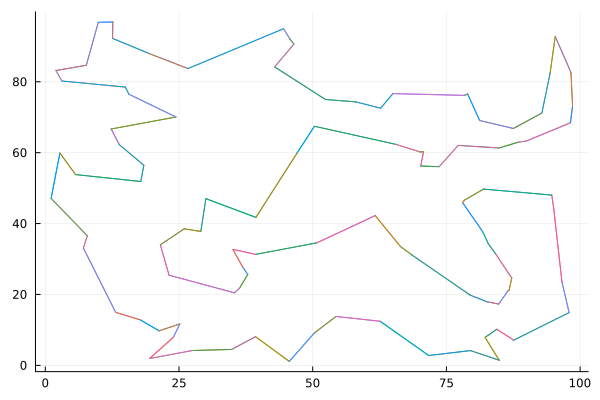

In [10]:
function plot_tour(X, Y, x)
    plot = Plots.plot()
    for (i, j) in selected_edges(x, size(x, 1))
        Plots.plot!([X[i], X[j]], [Y[i], Y[j]]; legend = false)
    end
    return plot
end

plot_tour(X, Y, value.(iterative_model[:x]))

In [22]:
function plot_tour_with_shopping(X,Y,n,k)
    x_val = value.(iterative_model[:x])
    z_val = value.(iterative_model[:z])

    p = Plots.plot(legend=false)
    for (i,j) in selected_edges(x_val,n)
        Plots.plot!([X[i],X[j]],[Y[i],Y[j]])
    end

    for i in 1:n
        items_count = sum(z_val[:,i])
        if items_count>0
            msize = 3 + items_count
            Plots.scatter!([X[i]],[Y[i]],
                color=:green,
                markersize=msize,
                label="")
        end
    end
    return p
end

plot_tour_with_shopping (generic function with 1 method)

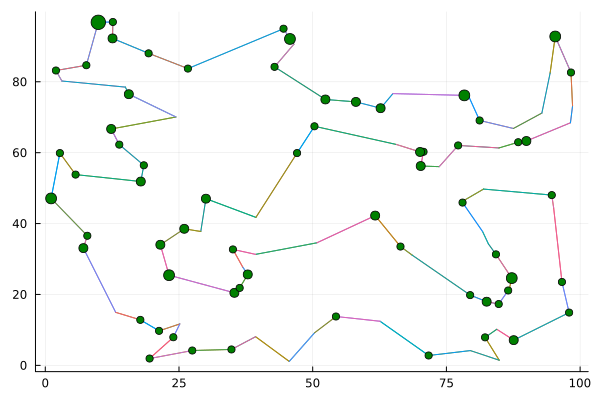

In [23]:
plot_tour_with_shopping(X,Y,n,k)

In [ ]:
using DataFrames

function get_shopping_df(n,k)
    z_val = value.(iterative_model[:z])
    df = DataFrame(Produkt = Int[], Miasto = Int[], Cena = Float64[])
    
end